# Ornstein-Uhlenbeck Process and Mean-Reversion
### A Theoretical Foundation — Implementation Notebook
**Aakash Agarwal**

---
This notebook is the computational companion to the OU theory document. Each section maps directly to the PDF. The goal is to make every major theoretical result visible and verifiable in code.


## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Shared OU parameters used throughout
kappa = 2.0    # mean-reversion speed
theta = 0.05   # long-run mean
sigma = 0.02   # diffusion
X0    = 0.08   # starting value
T     = 5.0    # horizon in years
dt    = 1/252  # daily steps
steps = int(T / dt)
t_grid = np.linspace(0, T, steps + 1)


---
## 1 — Stationarity and the Markov Property


### 1.1 GBM vs OU: Variance Over Time

The fundamental difference between GBM and OU is stationarity. GBM variance grows without bound as $\sigma^2 t$ — the process spreads indefinitely. OU variance converges to $\sigma^2 / 2\kappa$ — the process stabilises around $\theta$.

The plot below simulates 200 paths of each and tracks the cross-sectional variance over time. GBM variance grows linearly. OU variance flattens at the stationary level.


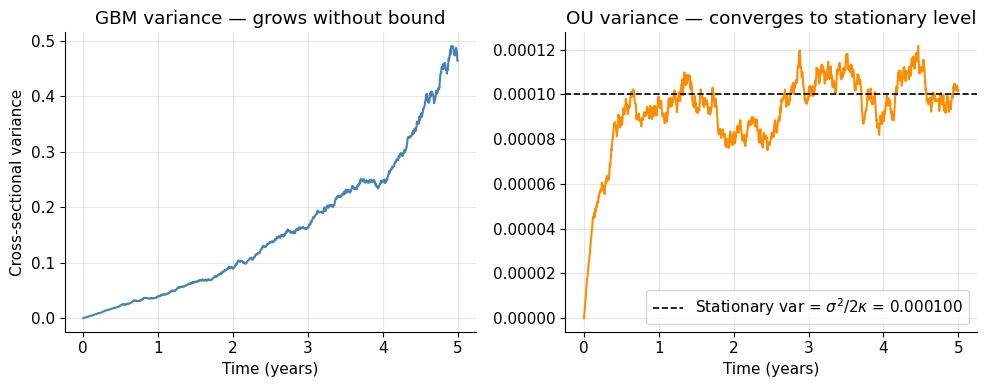

OU stationary variance theoretical: 0.000100
OU simulated variance at T=5:       0.000102


In [2]:
\
N = 200

# GBM paths
mu_gbm    = 0.05
sigma_gbm = 0.20
S0_gbm    = 1.0
dW        = rng.normal(0, np.sqrt(dt), (N, steps))
log_S     = np.zeros((N, steps + 1))
log_S[:, 0] = np.log(S0_gbm)
for t in range(steps):
    log_S[:, t+1] = log_S[:, t] + (mu_gbm - 0.5*sigma_gbm**2)*dt + sigma_gbm*dW[:, t]
S_gbm = np.exp(log_S)
gbm_var = S_gbm.var(axis=0)

# OU paths
X = np.zeros((N, steps + 1))
X[:, 0] = X0
dW_ou = rng.normal(0, np.sqrt(dt), (N, steps))
for t in range(steps):
    X[:, t+1] = X[:, t] + kappa*(theta - X[:, t])*dt + sigma*dW_ou[:, t]
ou_var = X.var(axis=0)

stationary_var = sigma**2 / (2 * kappa)

fig, axes = plt.subplots(1, 2)
axes[0].plot(t_grid, gbm_var, color='steelblue', lw=1.5)
axes[0].set_title('GBM variance — grows without bound')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Cross-sectional variance')

axes[1].plot(t_grid, ou_var, color='darkorange', lw=1.5)
axes[1].axhline(stationary_var, color='black', lw=1.2, ls='--',
                label=fr'Stationary var = $\sigma^2/2\kappa$ = {stationary_var:.6f}')
axes[1].set_title('OU variance — converges to stationary level')
axes[1].set_xlabel('Time (years)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"OU stationary variance theoretical: {stationary_var:.6f}")
print(f"OU simulated variance at T=5:       {ou_var[-1]:.6f}")


### 1.2 The Markov Property — Path History Is Irrelevant

Both GBM and OU are Markov. Two groups of paths started from different histories but arriving at the same value at time $t$ should have identical future distributions. We verify this: paths conditioned on the same current value evolve identically regardless of how they got there.


In [3]:
\
# Simulate two groups that arrive at the same value via different paths
n_paths = 500
steps_half = steps // 2

# Group A: starts at X0 = 0.08, arrives near theta naturally
# Group B: starts far above theta at 0.14, dragged down to near theta
XA = np.full(n_paths, 0.08)
XB = np.full(n_paths, 0.14)

dW_A = rng.normal(0, np.sqrt(dt), (n_paths, steps_half))
dW_B = rng.normal(0, np.sqrt(dt), (n_paths, steps_half))

for t in range(steps_half):
    XA = XA + kappa*(theta - XA)*dt + sigma*dW_A[:, t]
    XB = XB + kappa*(theta - XB)*dt + sigma*dW_B[:, t]

# Both groups now approximately near theta — evolve forward with same noise
dW_future = rng.normal(0, np.sqrt(dt), (n_paths, steps_half))
XA_future = np.zeros((n_paths, steps_half + 1)); XA_future[:, 0] = XA
XB_future = np.zeros((n_paths, steps_half + 1)); XB_future[:, 0] = XB

for t in range(steps_half):
    XA_future[:, t+1] = XA_future[:, t] + kappa*(theta - XA_future[:, t])*dt + sigma*dW_future[:, t]
    XB_future[:, t+1] = XB_future[:, t] + kappa*(theta - XB_future[:, t])*dt + sigma*dW_future[:, t]

print(f"Group A starting mean: {XA.mean():.4f}  |  Group B starting mean: {XB.mean():.4f}")
print(f"Group A terminal mean: {XA_future[:,-1].mean():.4f}  |  Group B terminal mean: {XB_future[:,-1].mean():.4f}")
print(f"Group A terminal std:  {XA_future[:,-1].std():.4f}  |  Group B terminal std:  {XB_future[:,-1].std():.4f}")
print()
print("Once paths are at similar values, their future distributions are indistinguishable — Markov property holds.")


Group A starting mean: 0.0507  |  Group B starting mean: 0.0506
Group A terminal mean: 0.0498  |  Group B terminal mean: 0.0498
Group A terminal std:  0.0103  |  Group B terminal std:  0.0103

Once paths are at similar values, their future distributions are indistinguishable — Markov property holds.


---
## 2 — Stationary Distribution and Half-Life


### 2.1 Stationary Distribution

As $t \to \infty$, the OU process settles into $\mathcal{N}(\theta, \sigma^2/2\kappa)$. We verify this by simulating a large number of paths to long horizon and comparing the terminal distribution to the theoretical stationary normal.


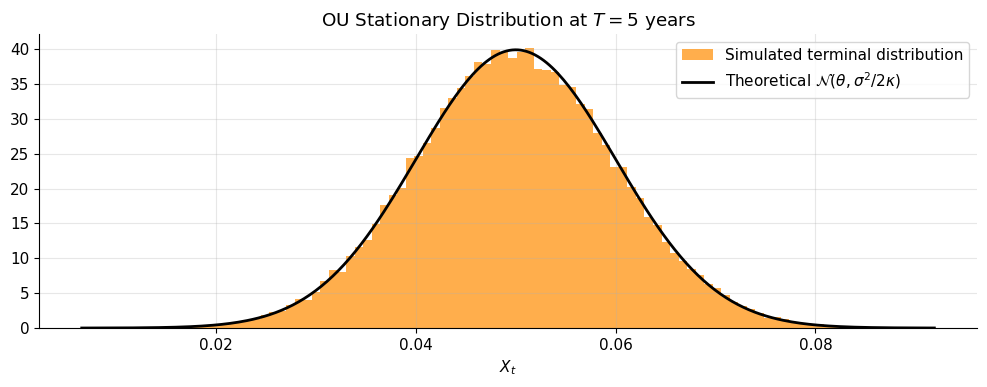

Theoretical mean: 0.05000  |  Simulated: 0.04998
Theoretical std:  0.01000  |  Simulated: 0.01003


In [4]:
\
N_stat = 50_000
X_stat = np.full(N_stat, X0)
dW_s   = rng.normal(0, np.sqrt(dt), (N_stat, steps))

for t in range(steps):
    X_stat = X_stat + kappa*(theta - X_stat)*dt + sigma*dW_s[:, t]

stat_mean = theta
stat_std  = np.sqrt(sigma**2 / (2*kappa))

x_range = np.linspace(X_stat.min(), X_stat.max(), 300)

plt.figure()
plt.hist(X_stat, bins=100, density=True, color='darkorange', alpha=0.7, label='Simulated terminal distribution')
plt.plot(x_range, norm.pdf(x_range, stat_mean, stat_std), 'k-', lw=2,
         label=fr'Theoretical $\mathcal{{N}}(\theta, \sigma^2/2\kappa)$')
plt.title(r'OU Stationary Distribution at $T = 5$ years')
plt.xlabel('$X_t$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical mean: {stat_mean:.5f}  |  Simulated: {X_stat.mean():.5f}")
print(f"Theoretical std:  {stat_std:.5f}  |  Simulated: {X_stat.std():.5f}")


### 2.2 Half-Life of Mean Reversion

The half-life $\tau_{1/2} = \log(2)/\kappa$ is the time for the expected deviation from $\theta$ to halve. We verify this numerically: track the average deviation of a large ensemble of paths over time and confirm it decays exponentially at rate $\kappa$, halving at $\tau_{1/2}$.


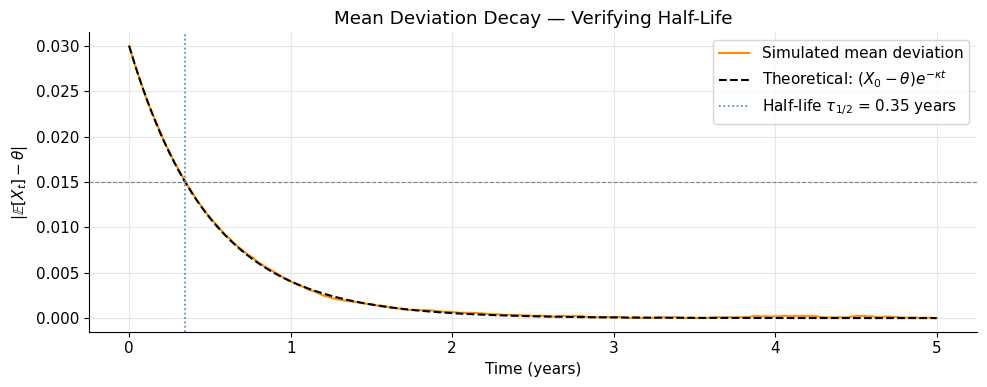

Theoretical half-life: log(2)/kappa = 0.3466 years (87 trading days)
Initial deviation: 0.0300
Expected deviation at half-life: 0.0150
Simulated deviation at half-life: 0.0152


In [5]:
\
N_hl  = 10_000
X_hl  = np.full(N_hl, X0)
deviations = [abs(X_hl.mean() - theta)]

dW_hl = rng.normal(0, np.sqrt(dt), (N_hl, steps))
for t in range(steps):
    X_hl = X_hl + kappa*(theta - X_hl)*dt + sigma*dW_hl[:, t]
    deviations.append(abs(X_hl.mean() - theta))

half_life = np.log(2) / kappa
theoretical_decay = abs(X0 - theta) * np.exp(-kappa * t_grid)

plt.figure()
plt.plot(t_grid, deviations, color='darkorange', lw=1.5, label='Simulated mean deviation')
plt.plot(t_grid, theoretical_decay, 'k--', lw=1.5, label=r'Theoretical: $(X_0-\theta)e^{-\kappa t}$')
plt.axvline(half_life, color='steelblue', lw=1.2, ls=':',
            label=fr'Half-life $\tau_{{1/2}}$ = {half_life:.2f} years')
plt.axhline(abs(X0 - theta)/2, color='grey', lw=0.8, ls='--')
plt.title('Mean Deviation Decay — Verifying Half-Life')
plt.xlabel('Time (years)')
plt.ylabel('$|\\mathbb{E}[X_t] - \\theta|$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical half-life: log(2)/kappa = {half_life:.4f} years ({half_life*252:.0f} trading days)")
print(f"Initial deviation: {abs(X0 - theta):.4f}")
print(f"Expected deviation at half-life: {abs(X0-theta)/2:.4f}")
print(f"Simulated deviation at half-life: {deviations[int(half_life/dt)]:.4f}")


---
## 3 — The OU SDE


### 3.1 Restoring Force — Drift as a Function of Position

The defining feature of the OU drift is that it is proportional to the deviation from $\theta$. The further $X$ is from $\theta$, the stronger the pull back. Below we plot the drift $\kappa(\theta - X)$ as a function of $X$ and overlay simulated path increments to confirm the restoring force is visible in the data.


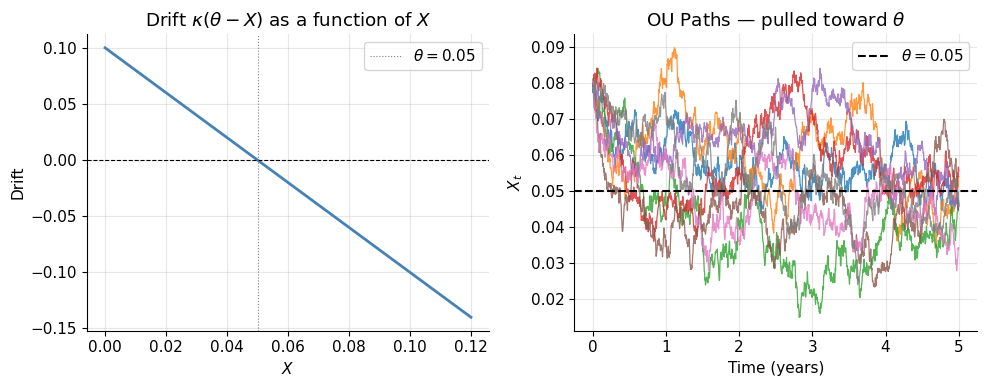

In [6]:
\
X_range = np.linspace(0.00, 0.12, 200)
drift   = kappa * (theta - X_range)

fig, axes = plt.subplots(1, 2)

axes[0].plot(X_range, drift, color='steelblue', lw=2)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].axvline(theta, color='grey', lw=0.8, ls=':', label=fr'$\theta = {theta}$')
axes[0].set_title(r'Drift $\kappa(\theta - X)$ as a function of $X$')
axes[0].set_xlabel('$X$')
axes[0].set_ylabel('Drift')
axes[0].legend()

# Simulate 8 paths and show restoring force visually
n_show = 8
X_show = np.zeros((n_show, steps + 1))
X_show[:, 0] = X0
dW_show = rng.normal(0, np.sqrt(dt), (n_show, steps))
for t in range(steps):
    X_show[:, t+1] = X_show[:, t] + kappa*(theta - X_show[:, t])*dt + sigma*dW_show[:, t]

for i in range(n_show):
    axes[1].plot(t_grid, X_show[i], lw=0.9, alpha=0.8)
axes[1].axhline(theta, color='black', lw=1.5, ls='--', label=fr'$\theta = {theta}$')
axes[1].set_title('OU Paths — pulled toward $\\theta$')
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('$X_t$')
axes[1].legend()

plt.tight_layout()
plt.show()


### 3.2 Effect of $\kappa$ on Reversion Speed

A higher $\kappa$ pulls paths back to $\theta$ more aggressively — shorter half-life, tighter clustering. A lower $\kappa$ allows paths to wander further and for longer.


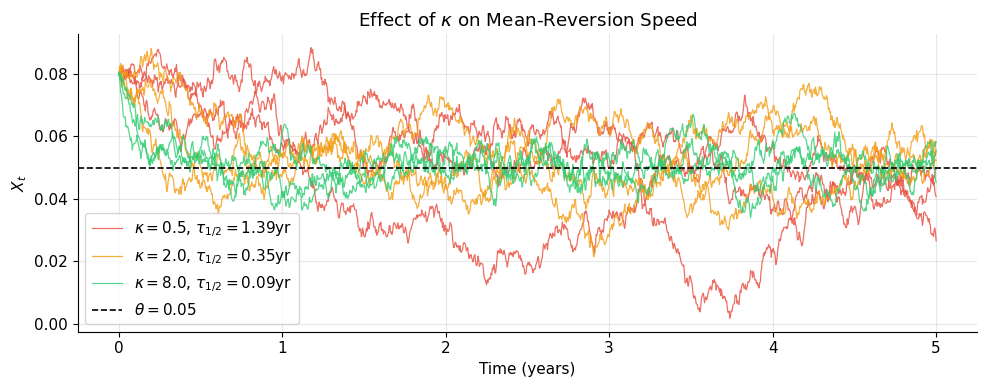

In [7]:
\
kappas = [0.5, 2.0, 8.0]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
n_show = 3

plt.figure()
for k, color in zip(kappas, colors):
    X_k = np.zeros((n_show, steps + 1))
    X_k[:, 0] = X0
    dW_k = rng.normal(0, np.sqrt(dt), (n_show, steps))
    for t in range(steps):
        X_k[:, t+1] = X_k[:, t] + k*(theta - X_k[:, t])*dt + sigma*dW_k[:, t]
    hl = np.log(2)/k
    for i in range(n_show):
        plt.plot(t_grid, X_k[i], lw=0.9, alpha=0.8, color=color,
                 label=fr'$\kappa={k}$, $\tau_{{1/2}}={hl:.2f}$yr' if i == 0 else '')

plt.axhline(theta, color='black', lw=1.2, ls='--', label=fr'$\theta={theta}$')
plt.title(r'Effect of $\kappa$ on Mean-Reversion Speed')
plt.xlabel('Time (years)')
plt.ylabel('$X_t$')
plt.legend()
plt.tight_layout()
plt.show()


---
## 4 — Analytical Solution


### 4.1 Closed-Form vs Euler-Maruyama

The OU process has an exact closed-form solution which tells us that $X_t$ is normally distributed with mean $\theta + (X_0 - \theta)e^{-\kappa t}$ and variance $\frac{\sigma^2}{2\kappa}(1 - e^{-2\kappa t})$. These are not approximations --- they are exact analytical results from the integrating factor derivation.

Euler-Maruyama has no knowledge of this. It simply steps forward 252 times using the discretised SDE increment, blindly accumulating drift and noise. The question this cell answers is: does Euler-Maruyama, after enough small steps, converge to the distribution the closed-form solution says it should?

The blue histogram samples directly from the exact closed-form distribution --- this is what the analytical solution says $X_T$ should look like. The orange histogram is what Euler-Maruyama produces. The black curve is the theoretical PDF confirming both. All three should agree --- and they do.


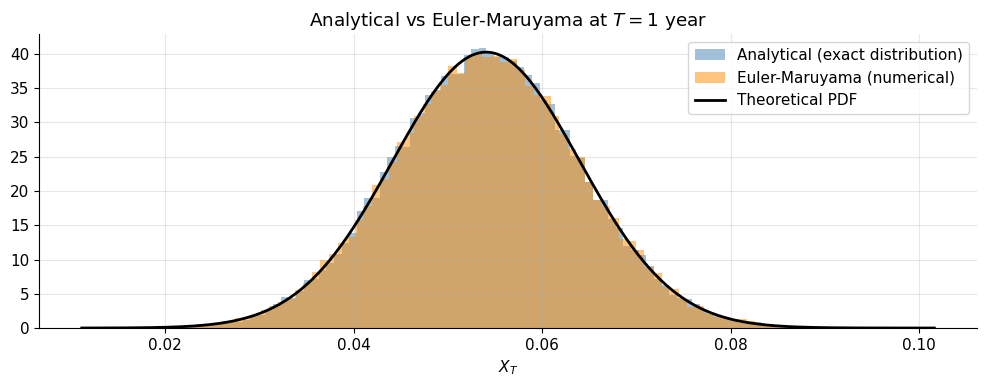

Theoretical mean: 0.05406
Analytical mean:  0.05408  |  EM mean: 0.05407
Theoretical std:  0.00991
Analytical std:   0.00985   |  EM std:  0.01000


In [8]:
\
N_cmp   = 50_000
t_check = 1.0   # check at T=1 year

# Analytical: compute exact mean and variance from closed-form formulas
mean_analytical = theta + (X0 - theta) * np.exp(-kappa * t_check)
var_analytical  = (sigma**2 / (2*kappa)) * (1 - np.exp(-2*kappa*t_check))

# Sample from the exact theoretical distribution
X_analytical = rng.normal(mean_analytical, np.sqrt(var_analytical), N_cmp)

# Euler-Maruyama: step by step, no knowledge of closed form
steps_check = int(t_check / dt)
X_em = np.full(N_cmp, X0)
dW_em = rng.normal(0, np.sqrt(dt), (N_cmp, steps_check))
for t in range(steps_check):
    X_em = X_em + kappa*(theta - X_em)*dt + sigma*dW_em[:, t]

x_range = np.linspace(min(X_analytical.min(), X_em.min()),
                      max(X_analytical.max(), X_em.max()), 300)

plt.figure()
plt.hist(X_analytical, bins=100, density=True, alpha=0.5, color='steelblue',
         label='Analytical (exact distribution)')
plt.hist(X_em,         bins=100, density=True, alpha=0.5, color='darkorange',
         label='Euler-Maruyama (numerical)')
plt.plot(x_range, norm.pdf(x_range, mean_analytical, np.sqrt(var_analytical)),
         'k-', lw=2, label='Theoretical PDF')
plt.title(r'Analytical vs Euler-Maruyama at $T=1$ year')
plt.xlabel('$X_T$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical mean: {mean_analytical:.5f}")
print(f"Analytical mean:  {X_analytical.mean():.5f}  |  EM mean: {X_em.mean():.5f}")
print(f"Theoretical std:  {np.sqrt(var_analytical):.5f}")
print(f"Analytical std:   {X_analytical.std():.5f}   |  EM std:  {X_em.std():.5f}")


### 4.2 Mean and Variance Convergence

The analytical solution tells us exactly how the mean and variance evolve over time. Mean decays exponentially from $X_0$ to $\theta$. Variance grows from zero and saturates at $\sigma^2/2\kappa$. We verify both trajectories numerically.


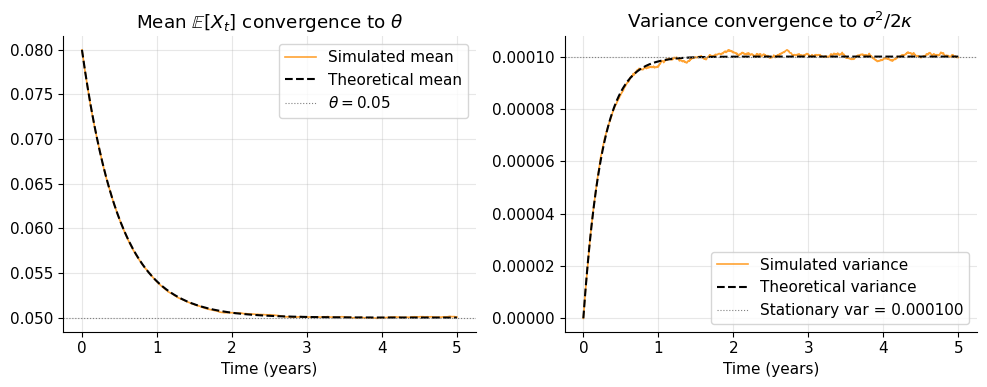

In [9]:
\
N_mv   = 20_000
X_mv   = np.full(N_mv, X0)
means  = [X_mv.mean()]
variances = [0.0]

dW_mv = rng.normal(0, np.sqrt(dt), (N_mv, steps))
for t in range(steps):
    X_mv = X_mv + kappa*(theta - X_mv)*dt + sigma*dW_mv[:, t]
    means.append(X_mv.mean())
    variances.append(X_mv.var())

theoretical_mean = theta + (X0 - theta) * np.exp(-kappa * t_grid)
theoretical_var  = (sigma**2 / (2*kappa)) * (1 - np.exp(-2*kappa*t_grid))

fig, axes = plt.subplots(1, 2)
axes[0].plot(t_grid, means, color='darkorange', lw=1.2, alpha=0.8, label='Simulated mean')
axes[0].plot(t_grid, theoretical_mean, 'k--', lw=1.5, label='Theoretical mean')
axes[0].axhline(theta, color='grey', lw=0.8, ls=':', label=fr'$\theta={theta}$')
axes[0].set_title(r'Mean $\mathbb{E}[X_t]$ convergence to $\theta$')
axes[0].set_xlabel('Time (years)')
axes[0].legend()

axes[1].plot(t_grid, variances, color='darkorange', lw=1.2, alpha=0.8, label='Simulated variance')
axes[1].plot(t_grid, theoretical_var, 'k--', lw=1.5, label='Theoretical variance')
axes[1].axhline(sigma**2/(2*kappa), color='grey', lw=0.8, ls=':',
                label=fr'Stationary var = {sigma**2/(2*kappa):.6f}')
axes[1].set_title(r'Variance convergence to $\sigma^2/2\kappa$')
axes[1].set_xlabel('Time (years)')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 5 — Bond Pricing Under Vasicek


### 5.1 The Affine Bond Pricing Formula

Under Vasicek, the zero-coupon bond price is $P(t,T) = A(t,T)e^{-B(t,T)r_t}$ — an affine function of the current short rate. We implement this formula and compute bond prices across maturities for different current rate levels.


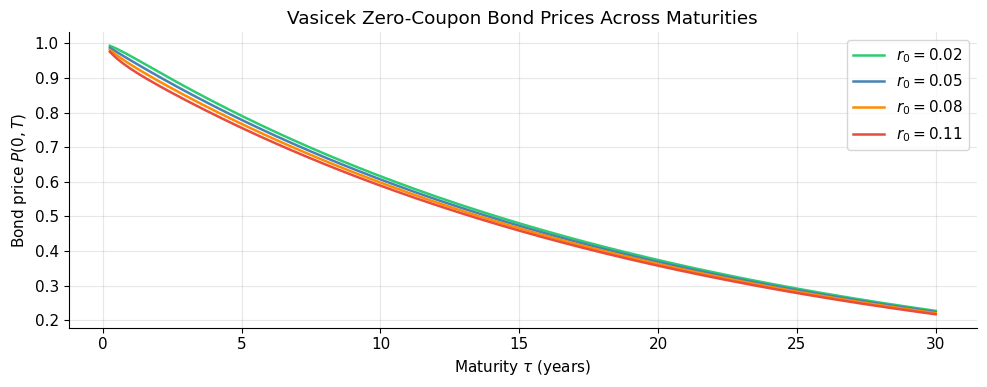

In [10]:
\
def vasicek_B(kappa, tau):
    return (1 - np.exp(-kappa * tau)) / kappa

def vasicek_lnA(kappa, theta, sigma, tau):
    B = vasicek_B(kappa, tau)
    return (theta - sigma**2 / (2*kappa**2)) * (B - tau) - sigma**2 / (4*kappa) * B**2

def vasicek_bond(r, kappa, theta, sigma, tau):
    B   = vasicek_B(kappa, tau)
    lnA = vasicek_lnA(kappa, theta, sigma, tau)
    return np.exp(lnA - B * r)

taus    = np.linspace(0.25, 30, 200)
r_levels = [0.02, 0.05, 0.08, 0.11]
colors   = ['#2ecc71', 'steelblue', 'darkorange', '#e74c3c']

plt.figure()
for r_val, color in zip(r_levels, colors):
    prices = vasicek_bond(r_val, kappa, theta, sigma, taus)
    plt.plot(taus, prices, lw=1.8, color=color, label=fr'$r_0={r_val:.2f}$')

plt.title('Vasicek Zero-Coupon Bond Prices Across Maturities')
plt.xlabel('Maturity $\\tau$ (years)')
plt.ylabel('Bond price $P(0, T)$')
plt.legend()
plt.tight_layout()
plt.show()


### 5.2 The Yield Curve

The yield on a zero-coupon bond is $y(\tau) = -\log P(0,\tau) / \tau$. The Vasicek model produces a yield curve whose shape depends on whether $r_0$ is above or below the long-run mean $\theta$. If $r_0 > \theta$ the curve is downward sloping (inverted); if $r_0 < \theta$ it is upward sloping (normal).


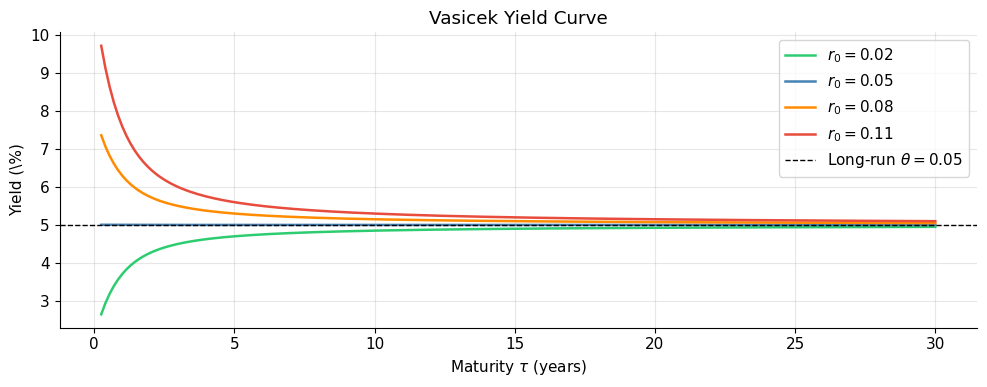

Yield curve shape:
  r0=0.02: short=2.64%  long=4.95%  -> normal (upward)
  r0=0.05: short=5.00%  long=5.00%  -> inverted (downward)
  r0=0.08: short=7.36%  long=5.05%  -> inverted (downward)
  r0=0.11: short=9.72%  long=5.10%  -> inverted (downward)


In [11]:
\
plt.figure()
for r_val, color in zip(r_levels, colors):
    prices = vasicek_bond(r_val, kappa, theta, sigma, taus)
    yields = -np.log(prices) / taus
    plt.plot(taus, yields * 100, lw=1.8, color=color, label=fr'$r_0={r_val:.2f}$')

plt.axhline(theta * 100, color='black', lw=1, ls='--', label=fr'Long-run $\theta={theta:.2f}$')
plt.title('Vasicek Yield Curve')
plt.xlabel('Maturity $\\tau$ (years)')
plt.ylabel('Yield (\\%)')
plt.legend()
plt.tight_layout()
plt.show()

print("Yield curve shape:")
for r_val in r_levels:
    short = -np.log(vasicek_bond(r_val, kappa, theta, sigma, 0.25)) / 0.25
    long  = -np.log(vasicek_bond(r_val, kappa, theta, sigma, 30.0)) / 30.0
    shape = "normal (upward)" if long > short else "inverted (downward)"
    print(f"  r0={r_val:.2f}: short={short*100:.2f}%  long={long*100:.2f}%  -> {shape}")


### 5.3 Two Routes, One Answer — Verifying the Bond Price

Every derivative pricing problem has two routes: the expectation route and the PDE route. In GBM the PDE applies only to derivatives written *on* $S$ — not to $S$ itself since $S$ is the traded underlying. In OU/Vasicek, $r$ is an unobservable factor, so the bond $P(r,t)$ is already a claim on that factor — the Vasicek PDE applies to the bond directly. The bond option $V(P,t)$ then adds another layer on top, and the PDE applies again. So unlike GBM which has one layer, OU has two:

```
GBM:  S_t  ──underlies──▶  V(S,t)         [PDE applies here only]

OU:   r_t  ──drives──▶  P(r,t)  ──underlies──▶  V(P,t)
                         [PDE here]              [PDE here too]
```

For the bond price specifically, both routes — the Gaussian expectation integral and the Vasicek PDE with affine ansatz — produce the same $A(t,T)e^{-B(t,T)r_t}$. We verify numerically that the closed-form formula agrees with Monte Carlo.


In [12]:
\
r0      = 0.05
tau_val = 5.0
N_mc    = 200_000
steps_mc = int(tau_val / dt)

# Monte Carlo: simulate r paths and compute average discount factor
r_mc = np.full(N_mc, r0)
cumulative_r = np.zeros(N_mc)
dW_mc = rng.normal(0, np.sqrt(dt), (N_mc, steps_mc))

for t in range(steps_mc):
    r_mc = r_mc + kappa*(theta - r_mc)*dt + sigma*dW_mc[:, t]
    cumulative_r += r_mc * dt

mc_price = np.mean(np.exp(-cumulative_r))

# Closed-form
cf_price = vasicek_bond(r0, kappa, theta, sigma, tau_val)

print(f"Bond price P(0, {tau_val}) with r0={r0}, kappa={kappa}, theta={theta}, sigma={sigma}")
print(f"  Closed-form (expectation route):  {cf_price:.6f}")
print(f"  Monte Carlo (200,000 paths):      {mc_price:.6f}")
print(f"  Difference:                       {abs(cf_price - mc_price):.6f}")


Bond price P(0, 5.0) with r0=0.05, kappa=2.0, theta=0.05, sigma=0.02
  Closed-form (expectation route):  0.778966
  Monte Carlo (200,000 paths):      0.778999
  Difference:                       0.000033


---
## 6 — Bond Option Pricing


### 6.1 Pricing a European Call on a Zero-Coupon Bond

The bond option price is found by applying the expectation route twice in sequence:

```
Step 1 — Bond price via expectation:
  r_t  ──▶  E^Q[e^{-∫r ds} | r_t]  ──▶  P(t,T) = A·e^{-B·r_t}

Step 2 — Option price via expectation, using P from Step 1 as underlying:
  P(T_opt, T)  ──▶  E^Q[e^{-∫r ds} · max(P - K, 0)]  ──▶  V = P·N(h) - K·P_opt·N(h - σ_P)
```

Step 1 closes because $\int_t^T r_s\,ds$ is Gaussian under OU — the expectation of its exponential has a known form. Step 2 closes because $P(T_\text{opt}, T) = A \cdot e^{-B \cdot r_{T_\text{opt}}}$ is log-normal (exponential of a Gaussian), so the expectation integral evaluates exactly like the Black-Scholes integral for a log-normal $S_T$. The Gaussian nature of OU propagates cleanly through both steps.

The resulting formula is structurally identical to Black-Scholes with $\sigma_P$ as the effective bond price volatility over the option life. We price across a range of strikes and verify against Monte Carlo.


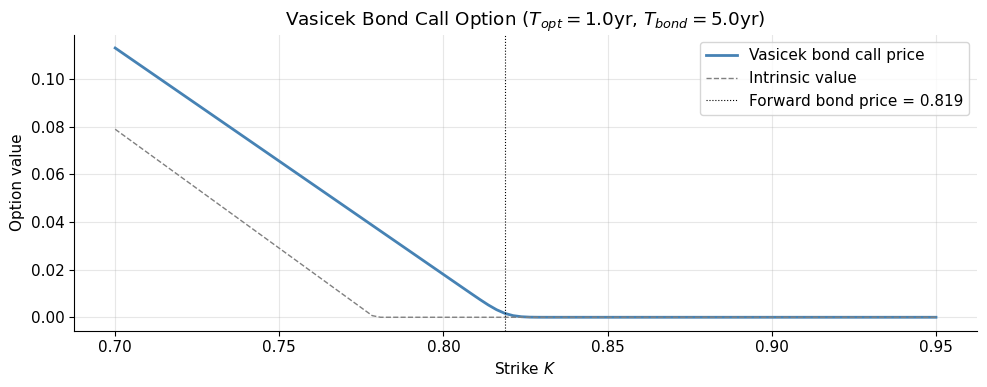

In [13]:
\
def vasicek_bond_option(r0, K, kappa, theta, sigma, T_opt, T_bond):
    P_bond = vasicek_bond(r0, kappa, theta, sigma, T_bond)
    P_opt  = vasicek_bond(r0, kappa, theta, sigma, T_opt)
    B_val  = vasicek_B(kappa, T_bond - T_opt)
    sigma_P = sigma * B_val * np.sqrt((1 - np.exp(-2*kappa*T_opt)) / (2*kappa))
    if sigma_P < 1e-10:
        return max(P_bond - K * P_opt, 0.0)
    h = np.log(P_bond / (K * P_opt)) / sigma_P + sigma_P / 2
    return P_bond * norm.cdf(h) - K * P_opt * norm.cdf(h - sigma_P)

r0     = 0.05
T_opt  = 1.0    # option expires in 1 year
T_bond = 5.0    # bond matures in 5 years

strikes  = np.linspace(0.70, 0.95, 100)
cf_atm   = vasicek_bond(r0, kappa, theta, sigma, T_bond - T_opt)  # forward bond price

option_prices = [vasicek_bond_option(r0, K, kappa, theta, sigma, T_opt, T_bond)
                 for K in strikes]
intrinsic     = [max(vasicek_bond(r0, kappa, theta, sigma, T_bond) - K, 0) for K in strikes]

plt.figure()
plt.plot(strikes, option_prices, color='steelblue', lw=2, label='Vasicek bond call price')
plt.plot(strikes, intrinsic,    color='grey',       lw=1, ls='--', label='Intrinsic value')
plt.axvline(cf_atm, color='black', lw=0.8, ls=':', label=f'Forward bond price = {cf_atm:.3f}')
plt.title(f'Vasicek Bond Call Option ($T_{{opt}}={T_opt}$yr, $T_{{bond}}={T_bond}$yr)')
plt.xlabel('Strike $K$')
plt.ylabel('Option value')
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Verify Against Monte Carlo

Same as the bond pricing verification — the closed-form option price must agree with the Monte Carlo expectation of $e^{-\int_0^{T_\text{opt}} r_s\,ds} \cdot \max(P(T_\text{opt}, T_\text{bond}) - K, 0)$.


In [14]:
\
K_atm    = cf_atm   # at-the-money strike
N_mc_opt = 200_000
steps_opt = int(T_opt / dt)

r_paths = np.full(N_mc_opt, r0)
cum_r   = np.zeros(N_mc_opt)
dW_opt  = rng.normal(0, np.sqrt(dt), (N_mc_opt, steps_opt))

for t in range(steps_opt):
    r_paths = r_paths + kappa*(theta - r_paths)*dt + sigma*dW_opt[:, t]
    cum_r  += r_paths * dt

# Bond price at T_opt for each path
tau_remain = T_bond - T_opt
P_at_Topt  = vasicek_bond(r_paths, kappa, theta, sigma, tau_remain)
payoff      = np.maximum(P_at_Topt - K_atm, 0)
mc_opt_price = np.mean(np.exp(-cum_r) * payoff)

cf_opt_price = vasicek_bond_option(r0, K_atm, kappa, theta, sigma, T_opt, T_bond)

print(f"ATM Bond Call Option (K = {K_atm:.4f})")
print(f"  Closed-form: {cf_opt_price:.6f}")
print(f"  Monte Carlo: {mc_opt_price:.6f}")
print(f"  Difference:  {abs(cf_opt_price - mc_opt_price):.6f}")


ATM Bond Call Option (K = 0.8189)
  Closed-form: 0.001551
  Monte Carlo: 0.001549
  Difference:  0.000002


---
## 7 — When the Underlying Is Non-Stationary


### 7.1 Individual Equity Prices Are Non-Stationary

OU requires a stationary variable. Individual equity prices trend upward over the long run — GBM is the correct model for them, not OU. We simulate two equity prices under GBM and show that their individual log-prices are non-stationary while their spread is stationary.


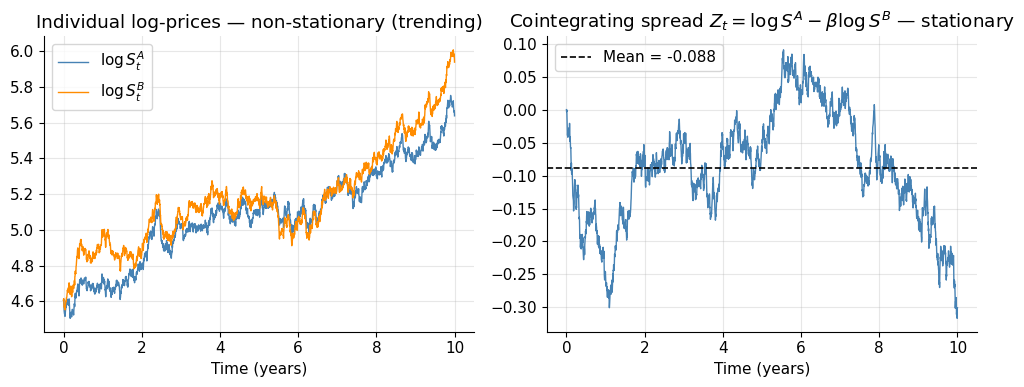

Log S_A: mean=5.09, std=0.27  (trending, non-stationary)
Log S_B: mean=5.17, std=0.28  (trending, non-stationary)
Spread:  mean=-0.0884, std=0.0834  (fluctuating around mean, stationary)


In [15]:
\
mu_eq    = 0.07
sigma_eq = 0.20
beta     = 1.0      # hedge ratio
T_eq     = 10.0
steps_eq = int(T_eq / (1/252))
N_eq     = 1

# Simulate two correlated GBM paths (same sector — high correlation)
rho   = 0.85
dW1   = rng.normal(0, np.sqrt(1/252), steps_eq)
dW2   = rho*dW1 + np.sqrt(1-rho**2)*rng.normal(0, np.sqrt(1/252), steps_eq)

logS_A = np.zeros(steps_eq + 1); logS_A[0] = np.log(100)
logS_B = np.zeros(steps_eq + 1); logS_B[0] = np.log(100)

for t in range(steps_eq):
    logS_A[t+1] = logS_A[t] + (mu_eq - 0.5*sigma_eq**2)/252 + sigma_eq*dW1[t]
    logS_B[t+1] = logS_B[t] + (mu_eq - 0.5*sigma_eq**2)/252 + sigma_eq*dW2[t]

spread = logS_A - beta * logS_B
t_eq   = np.linspace(0, T_eq, steps_eq + 1)

fig, axes = plt.subplots(1, 2)
axes[0].plot(t_eq, logS_A, color='steelblue',  lw=1, label=r'$\log S^A_t$')
axes[0].plot(t_eq, logS_B, color='darkorange', lw=1, label=r'$\log S^B_t$')
axes[0].set_title('Individual log-prices — non-stationary (trending)')
axes[0].set_xlabel('Time (years)')
axes[0].legend()

axes[1].plot(t_eq, spread, color='steelblue', lw=1)
axes[1].axhline(spread.mean(), color='black', lw=1.2, ls='--', label=f'Mean = {spread.mean():.3f}')
axes[1].set_title('Cointegrating spread $Z_t = \\log S^A - \\beta \\log S^B$ — stationary')
axes[1].set_xlabel('Time (years)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Log S_A: mean={logS_A.mean():.2f}, std={logS_A.std():.2f}  (trending, non-stationary)")
print(f"Log S_B: mean={logS_B.mean():.2f}, std={logS_B.std():.2f}  (trending, non-stationary)")
print(f"Spread:  mean={spread.mean():.4f}, std={spread.std():.4f}  (fluctuating around mean, stationary)")


### 7.2 Fitting OU to the Cointegrated Spread

Once we have identified a stationary spread, we fit an OU model to it. The fitted parameters give us the trading framework: $\theta$ is the equilibrium level, $\kappa$ determines the half-life of the trade, and the stationary distribution gives entry and exit thresholds.


In [16]:
\
# Fit OU to the spread via OLS on discretised increments
# dZ = kappa*(theta - Z)*dt + sigma*dW  =>  delta_Z = kappa*theta*dt - kappa*Z*dt + noise
from numpy.linalg import lstsq

Z      = spread
dZ     = np.diff(Z)
Z_lag  = Z[:-1]

# OLS: dZ = a + b*Z_lag  =>  a = kappa*theta*dt, b = -kappa*dt
A_mat  = np.column_stack([np.ones(len(Z_lag)), Z_lag])
coeffs, _, _, _ = lstsq(A_mat, dZ, rcond=None)
a, b   = coeffs

kappa_fit = -b / (1/252)
theta_fit = a / (-b)
resid     = dZ - (a + b * Z_lag)
sigma_fit = resid.std() / np.sqrt(1/252)
hl_fit    = np.log(2) / kappa_fit

print(f"Fitted OU parameters on cointegrating spread:")
print(f"  kappa = {kappa_fit:.3f}  (half-life = {hl_fit*252:.0f} trading days = {hl_fit:.2f} years)")
print(f"  theta = {theta_fit:.4f}  (equilibrium spread level)")
print(f"  sigma = {sigma_fit:.4f}  (diffusion)")
print(f"  Stationary std = {sigma_fit/np.sqrt(2*kappa_fit):.4f}")
print()
print(f"Trading thresholds (1 std from mean):")
stat_std_fit = sigma_fit / np.sqrt(2 * kappa_fit)
print(f"  Enter long spread:  Z < {theta_fit - stat_std_fit:.4f}")
print(f"  Enter short spread: Z > {theta_fit + stat_std_fit:.4f}")
print(f"  Exit:               Z near {theta_fit:.4f}")


Fitted OU parameters on cointegrating spread:
  kappa = 0.607  (half-life = 288 trading days = 1.14 years)
  theta = -0.1379  (equilibrium spread level)
  sigma = 0.1102  (diffusion)
  Stationary std = 0.1000

Trading thresholds (1 std from mean):
  Enter long spread:  Z < -0.2379
  Enter short spread: Z > -0.0378
  Exit:               Z near -0.1379
